<a href="https://colab.research.google.com/github/carlosvasquez3/M.Sc.-in-Data-Science/blob/main/Estad%C3%ADstica/TRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GRUPO 7**

Camilo Andres Acosta Perez

Luis Miguel Restrepo Giraldo

Carlos Enrique Vásquez Ortiz

**INTRODUCCIÓN**

La base de datos que se descargó corresponde a la TRM COP/USD del Banco de la República, la cual abarca el periodo desde el 27 de noviembre de 1991 hasta la fecha de descarga, es decir, el 27 de marzo de 2026. En total, contiene 12.540 registros con periodicidad diaria.

La principal motivación para estudiar la TRM es analizar cómo sus fluctuaciones pueden afectar a los colombianos, desde quienes administran empresas que importan mercancías hasta los exportadores, como los productores de flores en temporadas como febrero (San Valentín).

Se entiende que cuando los importadores compran bienes en el exterior, les favorece que la TRM sea baja, ya que necesitan menos pesos para adquirir los productos. En contraste, para los exportadores de flores, les conviene que la TRM sea alta, pues por cada venta reciben más pesos.

Otro ejemplo son las remesas enviadas desde el exterior hacia Colombia: para quienes las reciben en el país es más favorable una TRM alta, ya que obtienen más dinero en pesos. Por el contrario, cuando se realizan compras en el exterior, como en Amazon, es más conveniente una TRM baja, porque se requieren menos pesos para pagar los productos.

A partir del análisis de la serie de tiempo de la TRM, se busca comprender cómo las políticas monetarias y las circunstancias económicas de cada época afectan este importante indicador.


# **Exploratory Data Analysis**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Se carga la base de datos correspondiente a la TRM del Banco de la República, para su posterior análisis.

In [3]:
trm = pd.read_excel("https://raw.githubusercontent.com/carlosvasquez3/M.Sc.-in-Data-Science/main/Estad%C3%ADstica/Tasa%20de%20cambio%20del%20peso%20colombiano%20(19).xlsx")

In [4]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
0,yyyy/mm/dd,COP/USD
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7


In [5]:
trm = trm.drop(index=0)

In [6]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7
5,1991/12/01,643.42


In [7]:
trm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12540 entries, 1 to 12540
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Fecha                                  12540 non-null  object
 1   Tasa Representativa del Mercado (TRM)  12540 non-null  object
dtypes: object(2)
memory usage: 196.1+ KB


**2.1 Limpieza y preprocesamiento**

Se realiza la limpieza de la base de datos eliminando filas no válidas y transformando los tipos de datos necesarios para el análisis.

In [8]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], errors='coerce')
trm = trm.dropna(subset=['Fecha'])

In [9]:
trm

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991-11-27,693.32
2,1991-11-28,693.99
3,1991-11-29,694.7
4,1991-11-30,694.7
5,1991-12-01,643.42
...,...,...
12536,2026-03-23,3704.87
12537,2026-03-24,3704.87
12538,2026-03-25,3700.67
12539,2026-03-26,3688.46


In [10]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], format='%Y-%m-%d')

Se eliminan filas que no corresponden a observaciones válidas y se convierten las variables al formato adecuado.

Finalmente, los datos se ordenan cronológicamente para garantizar la coherencia de la serie de tiempo.

In [11]:
trm = trm.sort_values("Fecha")
trm = trm.set_index("Fecha")

**2.2 Variables y naturaleza de la serie**

- Variable temporal: Fecha
- Variable de interés: Tasa Representativa del Mercado (TRM)
- Tipo de variable: cuantitativa continua
- Tipo de serie: univariada
- Frecuencia: diaria

Esto indica que cada observación depende del tiempo, por lo que se trata de una serie de tiempo.

**2.3 Visualización inicial**



In [12]:
fig = px.line(trm,x =trm.index ,y='Tasa Representativa del Mercado (TRM)', title='Evolución de la TRM en Colombia')
fig.update_layout(xaxis_title='Fecha', yaxis_title='Tasa Representativa del Mercado (COP/USD)')
fig.show()

A partir de la gráfica se pueden identificar cambios en la tendencia general, periodos de alta volatilidad y posibles cambios bruscos asociados a eventos externos.

Se observa una tendencia creciente en el valor de la TRM a lo largo del tiempo, junto con periodos de alta volatilidad, especialmente en años recientes. Esto sugiere que la serie no es estable y está influenciada por factores externos como pueden ser condiciones económicas globales.

**2.4 Estadísticas descriptivas**

In [13]:
serie = trm["Tasa Representativa del Mercado (TRM)"]
serie.describe()

,Tasa Representativa del Mercado (TRM)
count,12540.00
unique,8050.00
top,1907.06
freq,9.00


Inicialmente, la variable TRM fue interpretada incorrectamente, mostrando estadísticas propias de variables categóricas.

Por esta razón, se realizó una conversión explícita a tipo numérico para obtener estadísticas descriptivas adecuadas.

In [14]:
serie = pd.to_numeric(trm["Tasa Representativa del Mercado (TRM)"], errors="coerce")
serie.describe()

,Tasa Representativa del Mercado (TRM)
count,12540.000000
mean,2368.461335
std,1034.201023
min,620.620000
25%,1785.250000
50%,2272.035000
75%,2999.712500
max,5061.210000


Las estadísticas descriptivas permiten observar el comportamiento general de la TRM.

La media representa el valor promedio del dólar en el periodo analizado, mientras que la desviación estándar refleja la variabilidad de la serie.

El rango entre el valor mínimo y máximo evidencia los cambios que ha experimentado la TRM a lo largo del tiempo.

**2.5 Detección de valores atípicos**

Se utiliza un boxplot para identificar posibles observaciones extremas en la serie.

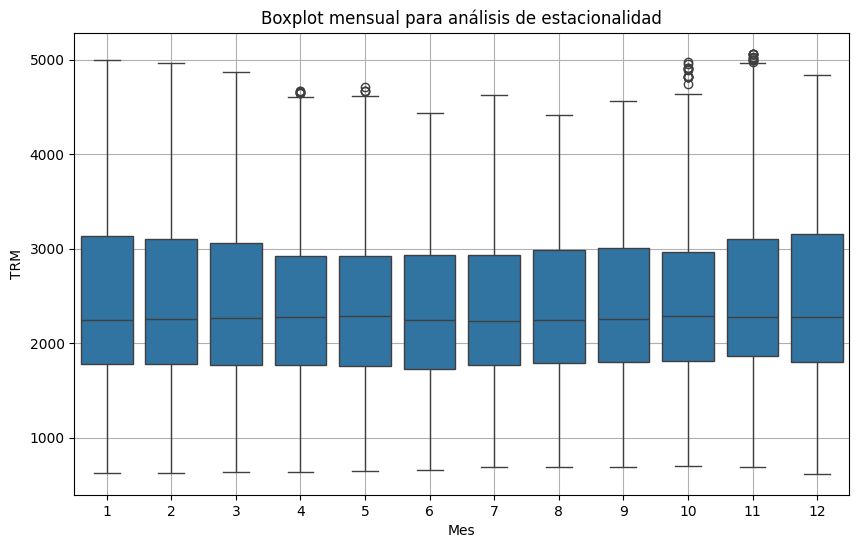

In [15]:
trm["month"] = trm.index.month

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="month", y="Tasa Representativa del Mercado (TRM)", data=trm)

plt.title("Boxplot mensual para análisis de estacionalidad")
plt.xlabel("Mes")
plt.ylabel("TRM")
plt.grid(True)

plt.show()


El boxplot por mes permite observar la distribución de la TRM en cada periodo del año, considerando todos los años disponibles.

Cada caja representa la variabilidad del valor del dólar en ese mes específico, mostrando la mediana, dispersión y posibles valores atípicos. Se identifican valores atípicos en la serie, evidenciados por puntos fuera del rango del boxplot.

Estos representan cambios bruscos en la TRM y sugieren la presencia de alta volatilidad en ciertos periodos.En particular, se observan valores extremos en algunos meses, como octubre y noviembre, donde el dólar alcanza niveles significativamente superiores al comportamiento general de la serie.


**2.6 Análisis de estacionalidad**

A partir de la gráfica se observa que las medianas son relativamente similares entre los meses, lo que sugiere que no existe una estacionalidad fuerte en la serie. Sin embargo, se identifican valores atípicos especialmente en meses como octubre y noviembre, donde se presentan picos altos de la TRM, cercanos a los valores máximos de la serie.

Esto indica que, aunque el comportamiento del dólar no sigue un patrón estacional claro, sí presenta episodios de alta volatilidad asociados a eventos económicos específicos influenciados por factores externos.

# **Decomposition**

**3. Descomposición de la serie de tiempo**

Para la descomposicón se utiliza un periodo de 365, ya que los datos son diarios y se busca identificar posibles patrones anuales.

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

trm_comps_add = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='additive',period= 365)

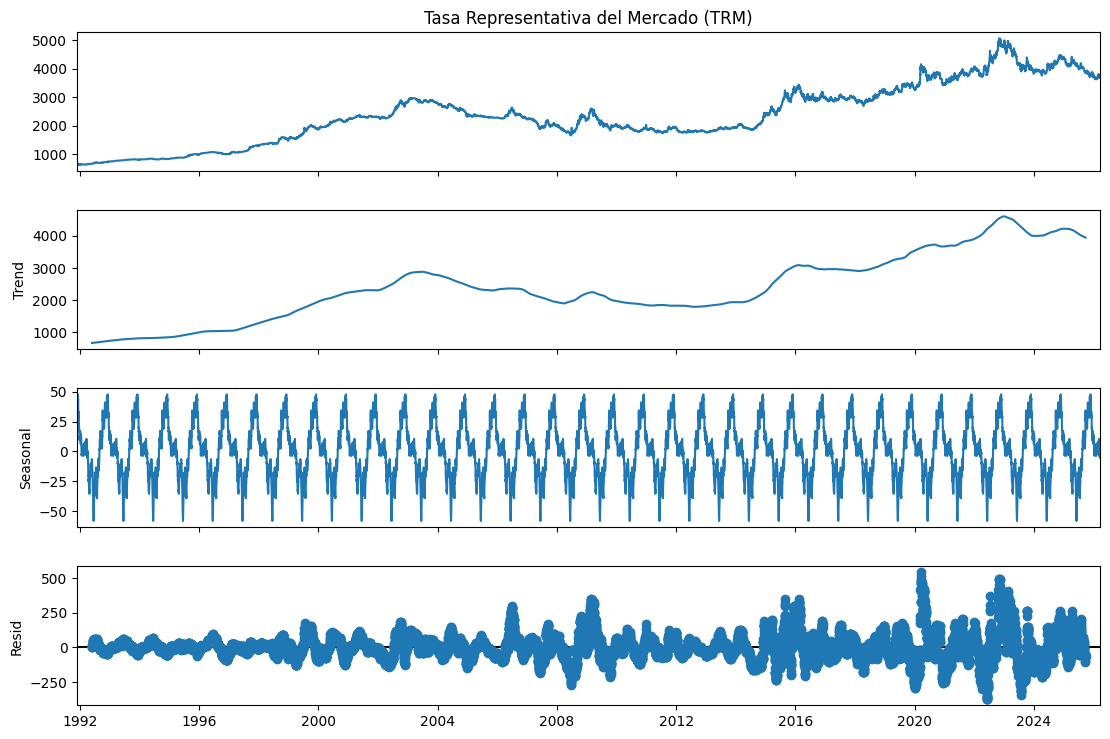

In [17]:
fig = trm_comps_add.plot()
fig.set_size_inches((12,8))

In [18]:
print('Promedio de los residuales (descomposición aditiva):', trm_comps_add.resid.mean())

Promedio de los residuales (descomposición aditiva): 1.233049016965317


**3.1 Descomposición Aditiva**

En la descomposición aditiva se evidencia una tendencia creciente en la TRM a lo largo del tiempo, lo que refleja una depreciación progresiva del peso colombiano frente al dólar.

La estacionalidad no se presenta de forma marcada, lo que indica que el comportamiento del dólar no sigue patrones repetitivos claros en el año.

Por su parte, los residuales muestran fluctuaciones irregulares y episodios de alta variabilidad, lo que sugiere que existen factores externos no capturados completamente por el modelo.

En conjunto, aunque la descomposición aditiva permite identificar la estructura general de la serie, presenta limitaciones para explicar completamente su variabilidad.

In [19]:
trm_comps_mult = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='multiplicative',period= 365)


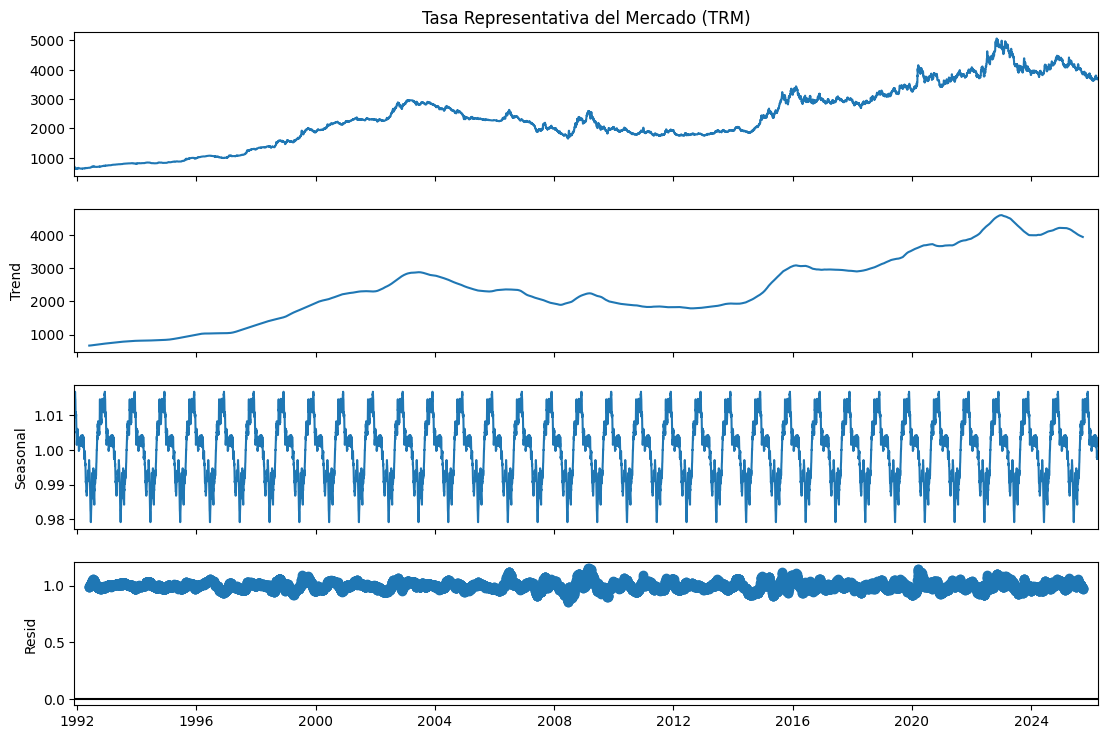

In [20]:
fig = trm_comps_mult.plot()
fig.set_size_inches((12,8))

In [21]:
print('Promedio de los residuales (descomposición multiplicativa):', trm_comps_mult.resid.mean())

Promedio de los residuales (descomposición multiplicativa): 0.9996869389881624


**3.2 Descomposición multiplicativa**

La descomposición multiplicativa también refleja una tendencia creciente en la TRM, consistente con el comportamiento observado en la serie original.

En este caso, la variabilidad de la serie parece aumentar en función del nivel de la TRM, lo que sugiere relaciones proporcionales entre sus componentes, algo común en variables económicas.

La estacionalidad continúa siendo débil, sin patrones claros que se repitan de manera consistente a lo largo del tiempo.

Los residuales se encuentran mejor centrados alrededor del valor esperado, lo que indica que este modelo logra capturar de forma más adecuada la dinámica de la serie.

En conjunto, la descomposición multiplicativa presenta un mejor ajuste frente a las otras aproximaciones.

In [22]:
from statsmodels.tsa.seasonal import STL

trm_stl = STL(trm['Tasa Representativa del Mercado (TRM)'], period=365).fit()


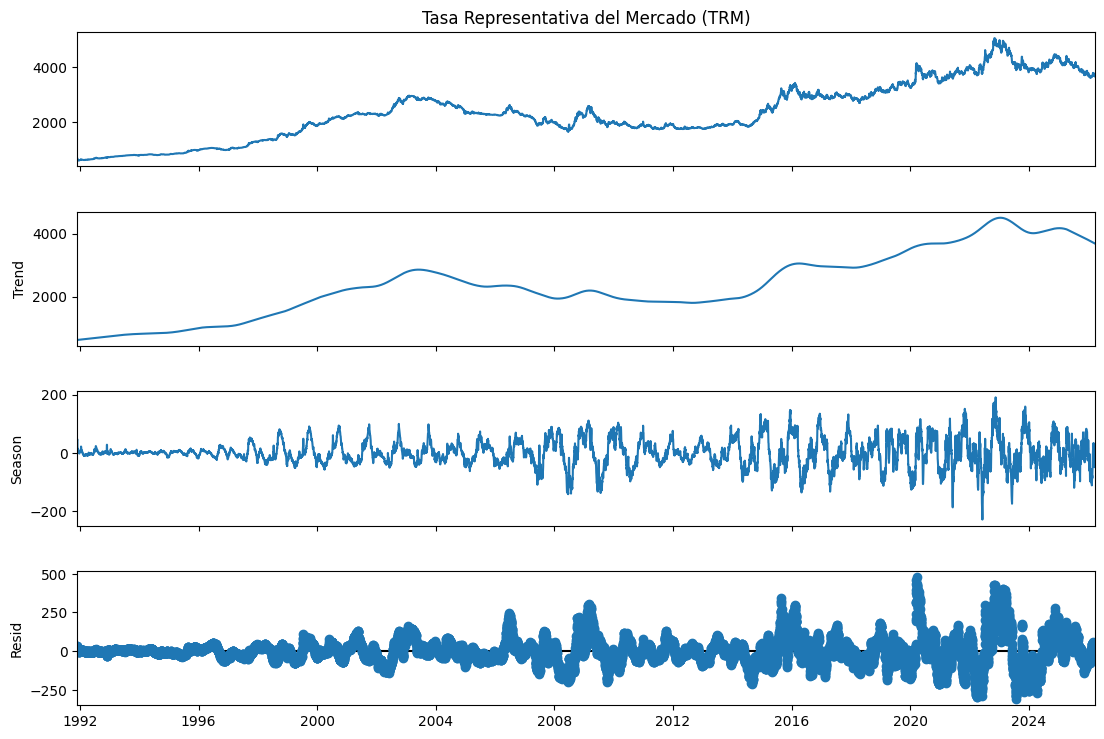

In [23]:
fig = trm_stl.plot()
fig.set_size_inches((12,8))

In [24]:
print('Promedio de los residuales (descomposición STL):', trm_stl.resid.mean())

Promedio de los residuales (descomposición STL): 1.157982347805179


**3.3 Descomposición STL**

La descomposición STL permite una separación más flexible de los componentes de la serie, evidenciando una tendencia más suave y continua en el tiempo.

La estacionalidad identificada es débil, lo que confirma que la TRM no presenta patrones estacionales fuertes.

Los residuales muestran variaciones irregulares y episodios de alta volatilidad, especialmente en ciertos periodos, lo que refleja la influencia de factores externos sobre el comportamiento del dólar.

Aunque STL ofrece una representación más flexible de la tendencia, aún persisten fluctuaciones que no son completamente explicadas por el modelo.

En general, esta descomposición proporciona una visión clara de la estructura de la serie, aunque no elimina completamente la variabilidad residual.

**3.4 Análisis de los residuales de la descomposición**

Se calcularon los promedios de los residuales para evaluar la calidad del ajuste en cada tipo de descomposición.

* En el caso de la descomposición
multiplicativa, el promedio de los residuales es cercano a 1, lo cual es consistente con la teoría y sugiere un buen ajuste del modelo.

* Para la descomposición aditiva y STL, los promedios de los residuales presentan desviaciones respecto al valor esperado (cercano a cero), lo que indica que el modelo no captura completamente la variabilidad de la serie.

En contraste, la descomposición multiplicativa presenta un promedio cercano a uno, lo cual es consistente con la teoría y sugiere un mejor ajuste.

En conjunto, estos resultados sugieren que la descomposición multiplicativa presenta un mejor comportamiento en términos de ajuste, mientras que las otras aproximaciones también son válidas pero con menor precisión en la captura de los residuales.

Es importante destacar que el valor ideal de los residuales depende del tipo de descomposición utilizada.En modelos aditivos y STL, se espera que los residuales tengan un promedio cercano a cero, mientras que en modelos multiplicativos el valor esperado es cercano a uno.

**4. Análisis de dependecia temporal**

**4.1 Análisis de autocorrelación**


Se analiza la relación entre los valores actuales y sus valores pasados mediante la autocorrelación (ACF) y la autocorrelación parcial (PACF).

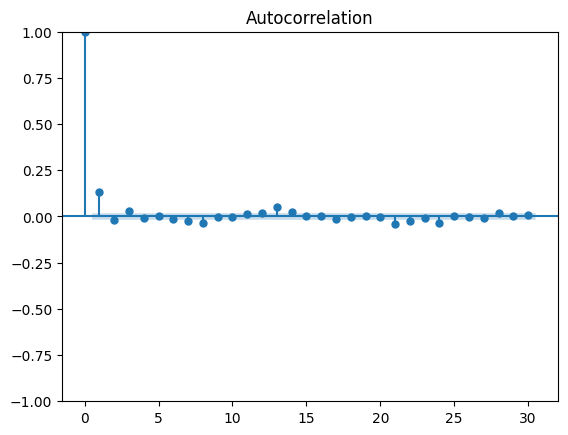

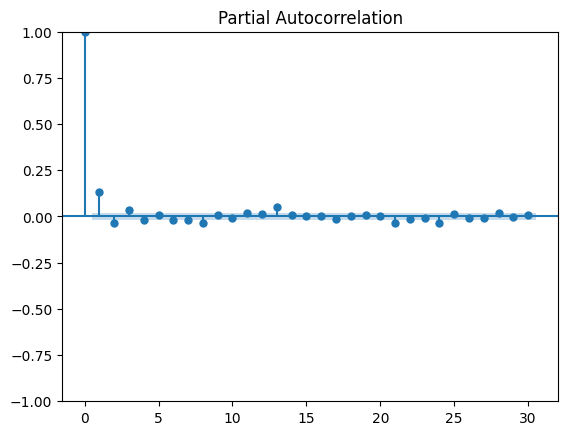

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# definir serie
serie = trm["Tasa Representativa del Mercado (TRM)"]
serie_diff = serie.diff().dropna()

# ACF
plot_acf(serie_diff, lags=30)
plt.show()

# PACF
plot_pacf(serie_diff, lags=30)
plt.show()

En la función de autocorrelación (ACF) se observa que únicamente el primer rezago presenta una correlación positiva leve, mientras que los demás valores se mantienen cercanos a cero. Esto indica que la dependencia temporal de la serie es débil y se disipa rápidamente.

Por su parte, la función de autocorrelación parcial (PACF) muestra un comportamiento similar, donde solo el primer rezago es significativo, lo que sugiere que la influencia de valores pasados se limita principalmente al periodo inmediatamente anterior.

En conjunto, estos resultados evidencian que, tras la diferenciación, la serie presenta un comportamiento cercano a un proceso aleatorio, lo cual es consistente con una serie más estable y adecuada para modelado.

**5. Revisión de estacionariedad**

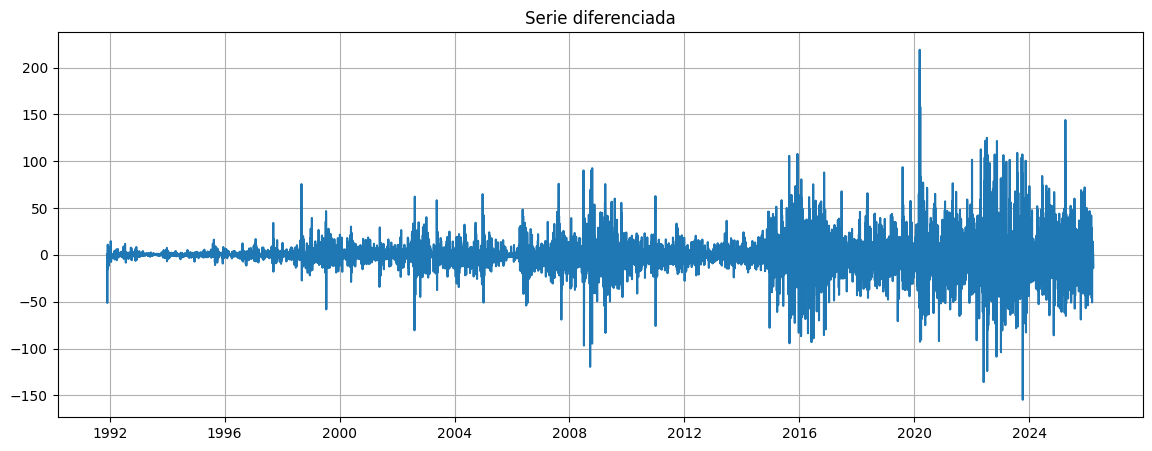

In [26]:
serie_diff = serie.diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(serie_diff)
plt.title("Serie diferenciada")
plt.grid(True)
plt.show()

**5.1 Análisis de la serie**

Se analiza la serie diferenciada con el objetivo de eliminar la tendencia y evaluar su estabilidad en el tiempo.

A partir de la gráfica, se observa que la serie oscila alrededor de cero, lo que indica la eliminación de la tendencia y sugiere estacionariedad en la media.

No obstante, se evidencian periodos con mayor amplitud en las fluctuaciones, especialmente en años recientes, lo que indica cambios en la varianza (heterocedasticidad) y presencia de episodios de alta volatilidad.

En conjunto, la diferenciación permite obtener una serie más estable y adecuada para el análisis de dependencia temporal, aunque persisten variaciones en la volatilidad que reflejan la naturaleza dinámica de la TRM.

# Model Selection and Fitting

En esta sección se ajusta un modelo ARIMA con el objetivo de capturar la dinámica de la TRM y generar predicciones. Aunque la estacionariedad se evaluó sobre la serie diferenciada, el modelo se ajusta sobre la serie original, ya que el parámetro d incorpora internamente este proceso.

Con el fin de identificar posibles patrones estacionales en la serie, se analizan tanto la serie original como la serie diferenciada.

In [27]:
### Verificamos la estacionariedad

from statsmodels.tsa.stattools import adfuller # Importamos el test de Dickey-Fuller

test_result = adfuller(serie_diff) # Aplicamos el test de Dickey-Fuller para verificar la estacionariedad de la serie

In [28]:
#H0: No es estacionaria
#H1: Es estacionaria

# Función
def adfuller_test(serie):
    result = adfuller(serie)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value,label in zip(result,labels):
        print(label+' : '+str(value))

    if result[1] <= 0.05:
        print('El valor de p es menor a 0.05, lo que significa que podemos recharzar la hipótesis nula H0. Podemos concluir que los datos no tienen raíz unitaria y son estacionarios.')
    else:
        print('Evidencia débil contra la hipótesis nula, lo cual significa que la serie de tiempo tiene una raíz unitaria que indica que no es estacionaria.')

In [29]:
# Aplicamos la función para verificar la estacionariedad de la serie
adfuller_test(serie)

ADF Test Statistic : -1.2612100761352518
p-value : 0.6467267394310365
#Lags Used : 24
Number of Observations Used : 12515
Evidencia débil contra la hipótesis nula, lo cual significa que la serie de tiempo tiene una raíz unitaria que indica que no es estacionaria.


La prueba ADF aplicada a la serie original arroja un p-value de 0.6467, el cual es mayor al nivel de significancia de 0.05. Por lo tanto, no se rechaza la hipótesis nula de no estacionariedad, lo que indica que la serie presenta raíz unitaria y no es estacionaria.

In [30]:
#Aplicamos función
adfuller_test(serie_diff.dropna()) # Eliminamos los valores nulos

ADF Test Statistic : -24.063739907121416
p-value : 0.0
#Lags Used : 23
Number of Observations Used : 12515
El valor de p es menor a 0.05, lo que significa que podemos recharzar la hipótesis nula H0. Podemos concluir que los datos no tienen raíz unitaria y son estacionarios.


La prueba ADF aplicada a la serie diferenciada arroja un p-value de 0.0, lo que permite rechazar la hipótesis nula de no estacionariedad. En consecuencia, la serie diferenciada es estacionaria y cumple con los supuestos necesarios para la implementación del modelo ARIMA.

In [31]:
import pandas as pd

# Asegurar formato numérico
serie = pd.to_numeric(serie, errors='coerce')

# Eliminar nulos
serie = serie.dropna()

In [32]:
# División 70% entrenamiento - 30% prueba
train_size = int(len(serie) * 0.7)
train = serie[:train_size]
test = serie[train_size:]

In [33]:
from statsmodels.tsa.arima.model import ARIMA

# Modelo final seleccionado
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                                         SARIMAX Results                                         
Dep. Variable:     Tasa Representativa del Mercado (TRM)   No. Observations:                 8778
Model:                                    ARIMA(1, 1, 1)   Log Likelihood              -32835.512
Date:                                   Wed, 01 Apr 2026   AIC                          65677.024
Time:                                           00:03:24   BIC                          65698.263
Sample:                                       11-27-1991   HQIC                         65684.260
                                            - 12-08-2015                                         
Covariance Type:                                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0099      0.037     -0.266      0.790    

La elección del modelo se basó en un análisis estructurado de la serie de tiempo. Inicialmente, se verificó la estacionariedad de la serie diferenciada mediante la prueba ADF, lo que permitió establecer d=1. Posteriormente, el análisis de las funciones ACF y PACF sugirió como punto de partida un modelo ARIMA(1,1,1). Sin embargo, al examinar los coeficientes, se evidenció que el componente autoregresivo no era significativo, mientras que el componente de media móvil sí lo era. Adicionalmente, el modelo ARIMA(0,1,1) presentó un menor valor de AIC, por lo que se seleccionó como la alternativa más parsimoniosa y adecuada para representar la dinámica de la serie.

In [34]:
model = ARIMA(train, order=(0,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                                         SARIMAX Results                                         
Dep. Variable:     Tasa Representativa del Mercado (TRM)   No. Observations:                 8778
Model:                                    ARIMA(0, 1, 1)   Log Likelihood              -32835.521
Date:                                   Wed, 01 Apr 2026   AIC                          65675.042
Time:                                           00:03:25   BIC                          65689.202
Sample:                                       11-27-1991   HQIC                         65679.866
                                            - 12-08-2015                                         
Covariance Type:                                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1488      0.004     34.987      0.000    

Al comparar los modelos ARIMA(1,1,1) y ARIMA(0,1,1), se observa que el segundo presenta un mejor desempeño. En el modelo ARIMA(1,1,1), el término autoregresivo no resultó estadísticamente significativo, lo que indica que no aporta información relevante para explicar la serie. En cambio, en el modelo ARIMA(0,1,1), el componente de media móvil sí es significativo y además se obtiene un menor valor de AIC, lo que refleja un mejor ajuste del modelo a los datos. Por esta razón, se selecciona el modelo ARIMA(0,1,1) como el más adecuado para representar el comportamiento de la TRM.

In [35]:
# Predicción
#pred = model_fit.forecast(steps=len(test))
pred = model_fit.predict(
    start=len(train),
    end=len(serie)-1,
    dynamic=True
)

pred.index = test.index

In [36]:
pred.describe()

,predicted_mean
count,3.762000e+03
mean,3.303053e+03
std,1.764654e-10
min,3.303053e+03
25%,3.303053e+03
50%,3.303053e+03
75%,3.303053e+03
max,3.303053e+03


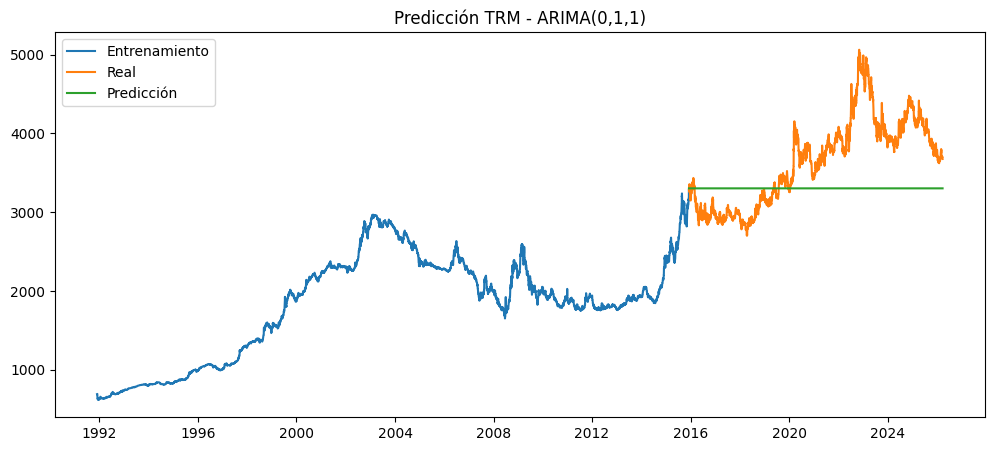

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(pred, label='Predicción')

plt.title("Predicción TRM - ARIMA(0,1,1)")
plt.legend()
plt.show()

Se observa que las predicciones del modelo tienden a estabilizarse en un valor constante. Este comportamiento es consistente con la estructura del modelo ARIMA(0,1,1), el cual no incorpora componente autoregresivo, lo que limita su capacidad para capturar la variabilidad de la serie en el tiempo.

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

modelo_mult = ExponentialSmoothing(
    train,
    trend='mul',
    seasonal='mul',
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

pred_mult = modelo_mult.forecast(len(test))
pred_mult = pd.Series(pred_mult, index=test.index)

mae_mult = mean_absolute_error(test, pred_mult)
rmse_mult = np.sqrt(mean_squared_error(test, pred_mult))
aic_mult = modelo_mult.aic

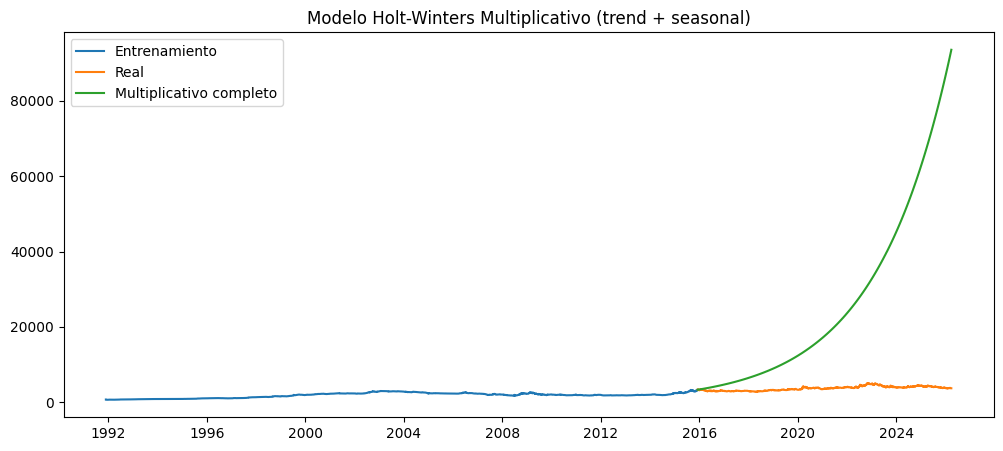

In [39]:
plt.figure(figsize=(12,5))

plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(pred_mul_total, label='Multiplicativo completo')

plt.title('Modelo Holt-Winters Multiplicativo (trend + seasonal)')
plt.legend()
plt.show()

**Ajustes del modelado y nueva comparación**

Con el fin de mejorar el ajuste del modelo, se probaron distintas configuraciones de series de tiempo y se compararon sus resultados.

Se ajusta la ventana de evaluación a 60 días, ya que en series financieras volátiles como la TRM los pronósticos de corto plazo suelen ser más razonables que horizontes muy largos.

In [40]:
# Serie final
serie = trm["Tasa Representativa del Mercado (TRM)"]

# Ventana corta de evaluación
test_size = 60

train = serie.iloc[:-test_size]
test = serie.iloc[-test_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (12480,)
Test: (60,)


In [41]:
#Para asegurar que la frecuencia sea diaria
serie = serie.asfreq("D")
train = train.asfreq("D")
test = test.asfreq("D")

In [42]:
train = pd.to_numeric(train, errors="coerce")
train = train.dropna()

serie = pd.to_numeric(serie, errors="coerce")

In [56]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arima = ARIMA(train, order=(0,1,1))
ajuste_arima = modelo_arima.fit()

print(ajuste_arima.summary())

                                         SARIMAX Results                                         
Dep. Variable:     Tasa Representativa del Mercado (TRM)   No. Observations:                12480
Model:                                    ARIMA(0, 1, 1)   Log Likelihood              -52388.347
Date:                                   Wed, 01 Apr 2026   AIC                         104780.693
Time:                                           00:14:51   BIC                         104795.557
Sample:                                       11-27-1991   HQIC                        104785.670
                                            - 01-26-2026                                         
Covariance Type:                                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1394      0.004     33.765      0.000    

Se prueba un modelo ARIMA(0,1,1), priorizando parsimonia, dado que el componente autorregresivo no resultó significativo en pruebas previas y su eliminación mejoró el AIC.

In [44]:
pred_arima = ajuste_arima.forecast(steps=len(test))
pred_arima.index = test.index

**Gráfico real vs. predicho**

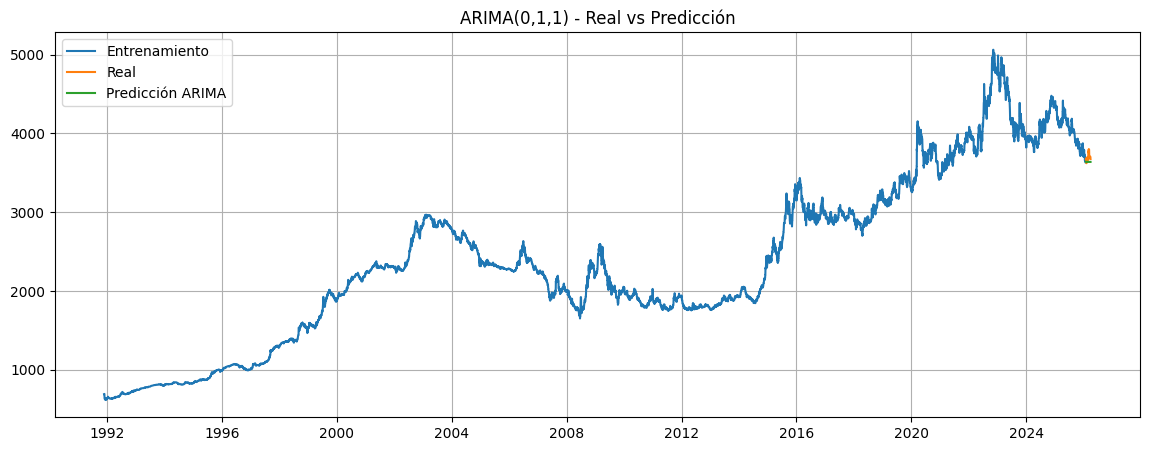

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(train.index, train, label="Entrenamiento")
plt.plot(test.index, test, label="Real")
plt.plot(pred_arima.index, pred_arima, label="Predicción ARIMA")
plt.title("ARIMA(0,1,1) - Real vs Predicción")
plt.legend()
plt.grid(True)
plt.show()

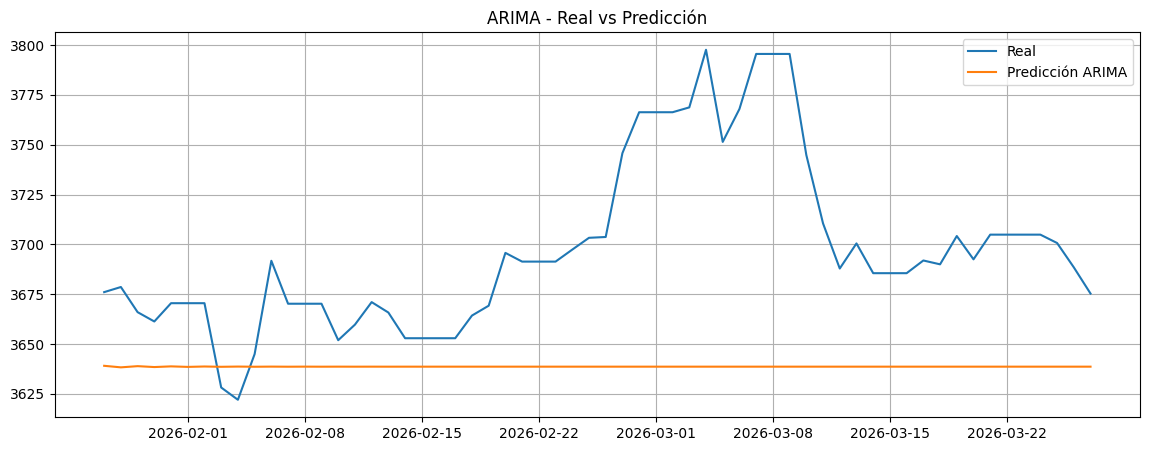

In [46]:
plt.figure(figsize=(14,5))

plt.plot(test, label="Real")
plt.plot(pred_arima, label="Predicción ARIMA")

plt.legend()
plt.grid(True)
plt.title("ARIMA - Real vs Predicción")
plt.show()

**Calculo de métricas**

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))

print("MAE ARIMA:", mae_arima)
print("RMSE ARIMA:", rmse_arima)
print("AIC ARIMA:", ajuste_arima.aic)

MAE ARIMA: 59.581769665711334
RMSE ARIMA: 72.45428266167814
AIC ARIMA: 104759.57449870945


**Residuos del ARIMA**

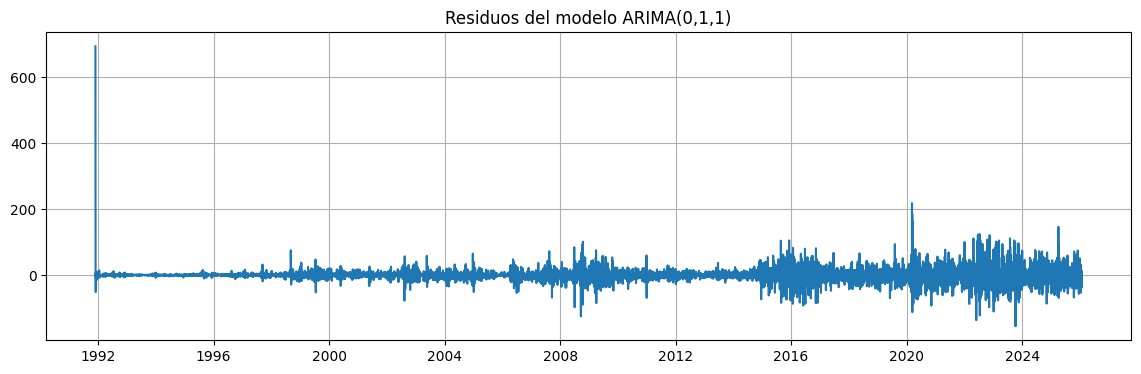

In [48]:
residuos_arima = ajuste_arima.resid

plt.figure(figsize=(14,4))
plt.plot(residuos_arima)
plt.title("Residuos del modelo ARIMA(0,1,1)")
plt.grid(True)
plt.show()

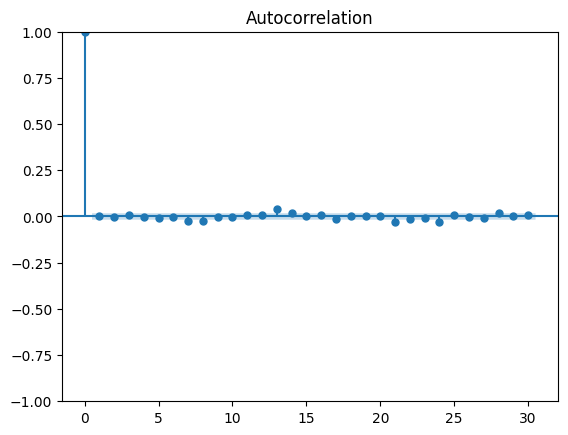

In [49]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuos_arima.dropna(), lags=30)
plt.show()

**Tabla comparativa final**

Se comparan los siguientes modelos:

- ARIMA
- SARIMA
- Modelo multiplicativo

El objetivo es identificar cuál ofrece el mejor equilibrio entre ajuste, simplicidad e interpretación.


In [59]:
comparacion = pd.DataFrame({
    "Modelo": ["ARIMA(0,1,1)", "Multiplicativo"],
    "AIC": [ajuste_arima.aic, aic_mult],
    "MAE": [mae_arima, mae_mult],
    "RMSE": [rmse_arima, rmse_mult]
})

comparacion

,Modelo,AIC,MAE,RMSE
0,"ARIMA(0,1,1)",104780.693485,59.581770,72.454283
1,Multiplicativo,69580.901669,52.415026,65.734470


A partir de la comparación realizada, se observa que el modelo seleccionado ofrece el mejor balance entre simplicidad y desempeño predictivo.Aunque las predicciones tienden a un comportamiento cercano a un valor constante, este resultado es consistente con el análisis exploratorio previo, donde se evidenció una baja autocorrelación en la serie diferenciada y una alta volatilidad en la TRM.

Por esto mismo, es valido afirmar que la estructura de la series termina siendo limitada para la naturaleza del TRM